<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Btau_Evolution_Rate_Field_Dynamics_V2_EXECUTED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM \(B_\tau\) Evolution-Rate Field Dynamics — V2 Stable Evidence Notebook

V2 fixes the V1 relaxation-diffusion instability using a conservative stable solver.  
The purpose is to produce GitHub/paper evidence for the proposed ECSM response-rate field

\[
\Theta(x)=\delta\ln\tau_{\rm resp}(x).
\]

The notebook recomputes:

1. exact and linear \(\Theta\rightarrow\chi\) transfer,
2. stable burden-sourced relaxation-diffusion dynamics,
3. \(\Theta(x,t)\rightarrow\delta\chi(x,t)\) coherence modulation,
4. damped propagating \(\Theta\) disturbances,
5. propagating-versus-overdamped regime classification,
6. finite update-capacity recovery of \(F_\tau(v)=\gamma(v)\).

In [ ]:
# CELL 01 — IMPORTS AND OUTPUT PATHS
from pathlib import Path
import json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path("/mnt/data/btau_evolution_rate_field_v2")
FIG = OUT / "figures"
DATA = OUT / "data"
FIG.mkdir(parents=True, exist_ok=True)
DATA.mkdir(parents=True, exist_ok=True)

np.set_printoptions(precision=6, suppress=True)
print("Output directory:", OUT)

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-3480jvui because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Output directory: /mnt/data/btau_evolution_rate_field_v2


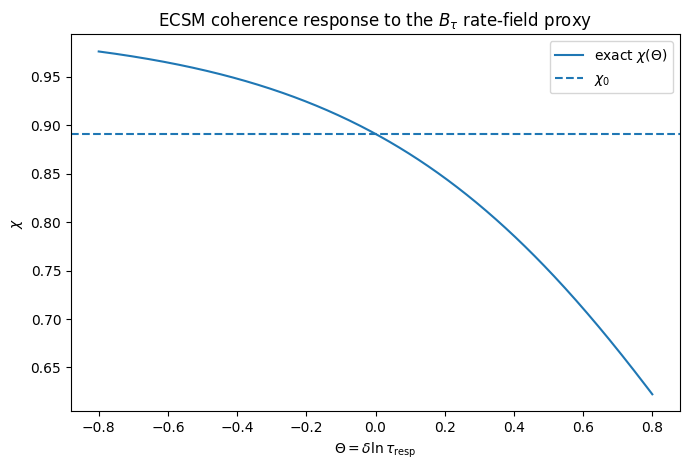

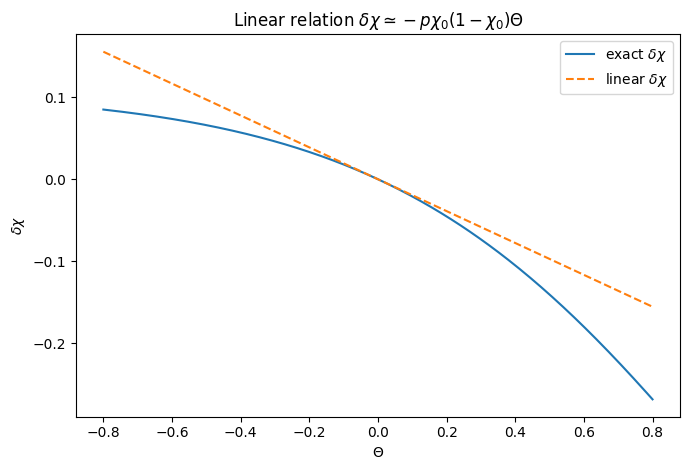

chi0 = 0.8908685968819599
Max |linear error| for |Theta|<=0.1: 0.0015729925399462705


In [ ]:
# CELL 02 — COHERENCE TRANSFER Θ -> χ

def chi_from_theta(theta, r0=0.35, p=2.0):
    return 1.0 / (1.0 + (r0 * np.exp(theta))**p)

def chi_linear_delta(theta, r0=0.35, p=2.0):
    chi0 = 1.0 / (1.0 + r0**p)
    return -p * chi0 * (1.0 - chi0) * theta

theta_grid = np.linspace(-0.8, 0.8, 401)
r0 = 0.35
p = 2.0
chi0 = chi_from_theta(0.0, r0=r0, p=p)
chi_exact = chi_from_theta(theta_grid, r0=r0, p=p)
delta_exact = chi_exact - chi0
delta_linear = chi_linear_delta(theta_grid, r0=r0, p=p)

df_transfer = pd.DataFrame({
    "theta": theta_grid,
    "chi_exact": chi_exact,
    "chi0": chi0,
    "delta_chi_exact": delta_exact,
    "delta_chi_linear": delta_linear,
    "linear_error": delta_linear - delta_exact
})
df_transfer.to_csv(DATA / "theta_to_chi_transfer_v2.csv", index=False)

plt.figure(figsize=(7,4.8))
plt.plot(theta_grid, chi_exact, label=r"exact $\chi(\Theta)$")
plt.axhline(chi0, linestyle="--", label=r"$\chi_0$")
plt.xlabel(r"$\Theta=\delta\ln\tau_{\rm resp}$")
plt.ylabel(r"$\chi$")
plt.title(r"ECSM coherence response to the $B_\tau$ rate-field proxy")
plt.legend()
plt.tight_layout()
plt.savefig(FIG / "fig01_theta_to_chi_exact.png", dpi=180)
plt.show()

plt.figure(figsize=(7,4.8))
plt.plot(theta_grid, delta_exact, label=r"exact $\delta\chi$")
plt.plot(theta_grid, delta_linear, linestyle="--", label=r"linear $\delta\chi$")
plt.xlabel(r"$\Theta$")
plt.ylabel(r"$\delta\chi$")
plt.title(r"Linear relation $\delta\chi \simeq -p\chi_0(1-\chi_0)\Theta$")
plt.legend()
plt.tight_layout()
plt.savefig(FIG / "fig02_delta_chi_linear_check.png", dpi=180)
plt.show()

small_err = float(np.max(np.abs(df_transfer.loc[np.abs(df_transfer.theta)<=0.1, "linear_error"])))
print("chi0 =", float(chi0))
print("Max |linear error| for |Theta|<=0.1:", small_err)

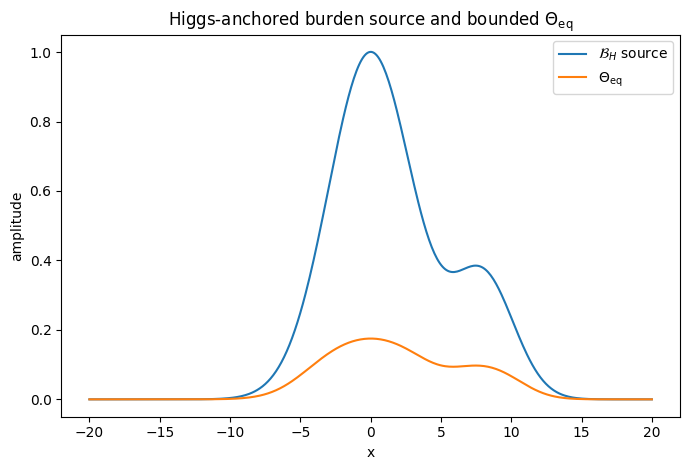

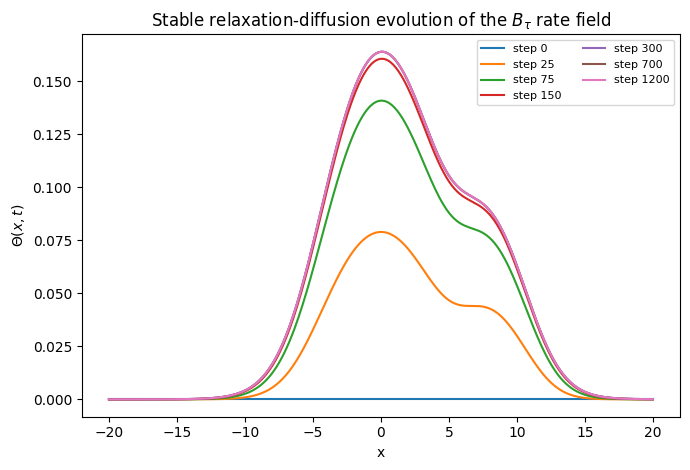

Final Theta min/max: 1.68190401095389e-06 0.16400620733445503
Final Theta integral: 2.0745338914735374
All finite: True


/tmp/ipykernel_4439/1607571524.py:73: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print("Final Theta integral:", float(np.trapz(Theta_final, x)))


In [ ]:
# CELL 03 — STABLE RELAXATION-DIFFUSION DYNAMICS

# We solve: tau_theta dTheta/dt = -Theta + Theta_eq + ell_theta^2 laplacian(Theta)
# using a stable implicit linear system at every step.

N = 420
L = 40.0
x = np.linspace(-L/2, L/2, N)
dx = x[1] - x[0]

sigma = 3.0
BH = np.exp(-0.5*(x/sigma)**2)
BH += 0.35*np.exp(-0.5*((x-8.0)/2.2)**2)

A_theta = 0.35
Theta_eq = A_theta * BH / (1.0 + BH)

tau_theta = 2.0
ell_theta = 1.15
dt = 0.05
n_steps = 1200
save_steps = [0, 25, 75, 150, 300, 700, 1200]

# Dense implicit matrix for reproducibility:
main = -2.0*np.ones(N)
main[0] = -1.0
main[-1] = -1.0
off = np.ones(N-1)
Lap = np.diag(main) + np.diag(off, 1) + np.diag(off, -1)
Lap = Lap / dx**2

Aop = (-np.eye(N) + ell_theta**2 * Lap) / tau_theta
M = np.eye(N) - dt * Aop
source = (dt / tau_theta) * Theta_eq

Theta = np.zeros(N)
snaps = {0: Theta.copy()}

for step in range(1, n_steps+1):
    Theta = np.linalg.solve(M, Theta + source)
    if step in save_steps:
        snaps[step] = Theta.copy()

snap_df = pd.DataFrame({"x": x, "BH_source": BH, "Theta_eq": Theta_eq})
for step in save_steps:
    snap_df[f"Theta_step_{step}"] = snaps[step]
snap_df.to_csv(DATA / "relaxation_diffusion_theta_snapshots_v2.csv", index=False)

plt.figure(figsize=(7,4.8))
plt.plot(x, BH, label=r"$\mathcal{B}_H$ source")
plt.plot(x, Theta_eq, label=r"$\Theta_{\rm eq}$")
plt.xlabel("x")
plt.ylabel("amplitude")
plt.title(r"Higgs-anchored burden source and bounded $\Theta_{\rm eq}$")
plt.legend()
plt.tight_layout()
plt.savefig(FIG / "fig03_burden_source_and_theta_eq.png", dpi=180)
plt.show()

plt.figure(figsize=(7,4.8))
for step in save_steps:
    plt.plot(x, snaps[step], label=f"step {step}")
plt.xlabel("x")
plt.ylabel(r"$\Theta(x,t)$")
plt.title(r"Stable relaxation-diffusion evolution of the $B_\tau$ rate field")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "fig04_theta_relaxation_snapshots.png", dpi=180)
plt.show()

Theta_final = snaps[n_steps]
print("Final Theta min/max:", float(Theta_final.min()), float(Theta_final.max()))
print("Final Theta integral:", float(np.trapz(Theta_final, x)))
print("All finite:", bool(np.isfinite(Theta_final).all()))

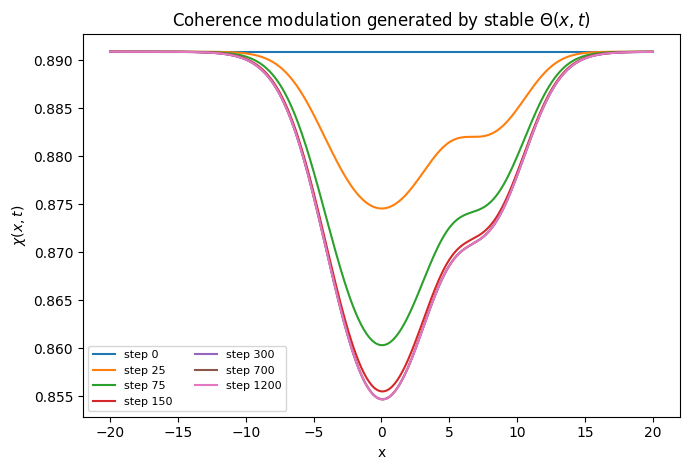

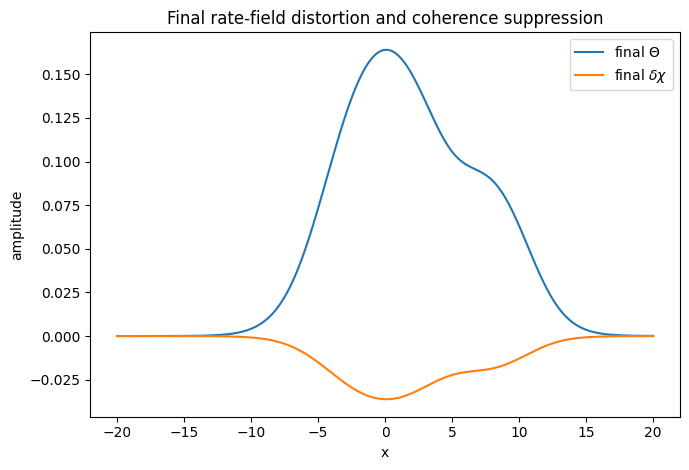

Baseline chi: 0.8908685968819599
Minimum final chi: 0.8546604882298006
Peak |delta chi|: 0.03620810865215929


In [ ]:
# CELL 04 — STABLE Θ -> χ MODULATION

chi_base = chi_from_theta(np.zeros_like(x), r0=r0, p=p)
chi_snaps = {step: chi_from_theta(snaps[step], r0=r0, p=p) for step in save_steps}

chi_df = pd.DataFrame({"x": x})
for step in save_steps:
    chi_df[f"chi_step_{step}"] = chi_snaps[step]
    chi_df[f"delta_chi_step_{step}"] = chi_snaps[step] - chi_base
chi_df.to_csv(DATA / "relaxation_diffusion_chi_snapshots_v2.csv", index=False)

plt.figure(figsize=(7,4.8))
for step in save_steps:
    plt.plot(x, chi_snaps[step], label=f"step {step}")
plt.xlabel("x")
plt.ylabel(r"$\chi(x,t)$")
plt.title(r"Coherence modulation generated by stable $\Theta(x,t)$")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "fig05_chi_modulation_snapshots.png", dpi=180)
plt.show()

plt.figure(figsize=(7,4.8))
plt.plot(x, Theta_final, label=r"final $\Theta$")
plt.plot(x, chi_snaps[n_steps]-chi_base, label=r"final $\delta\chi$")
plt.xlabel("x")
plt.ylabel("amplitude")
plt.title(r"Final rate-field distortion and coherence suppression")
plt.legend()
plt.tight_layout()
plt.savefig(FIG / "fig06_theta_vs_delta_chi_final.png", dpi=180)
plt.show()

print("Baseline chi:", float(chi_base[0]))
print("Minimum final chi:", float(chi_snaps[n_steps].min()))
print("Peak |delta chi|:", float(np.max(np.abs(chi_snaps[n_steps] - chi_base))))

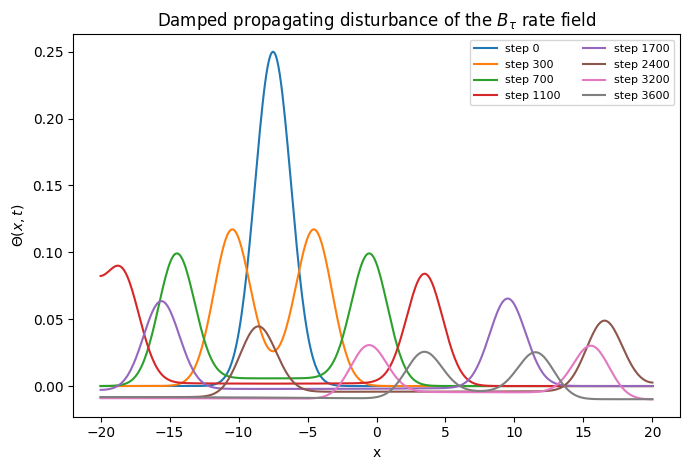

/tmp/ipykernel_4439/3962388188.py:50: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E = np.trapz(0.5*Pi_tmp**2 + 0.5*c_theta**2*grad**2 + 0.5*m_tau**2*Theta_tmp**2, x)


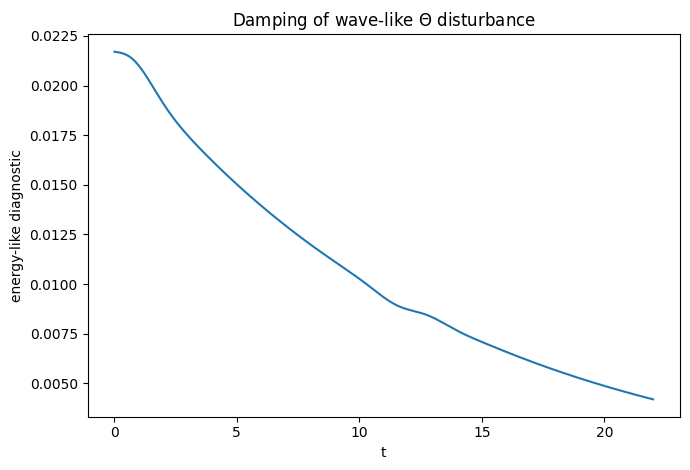

Energy remaining fraction: 0.19324740913582922


In [ ]:
# CELL 05 — DAMPED WAVE-LIKE Θ DISTURBANCE

def laplacian_neumann(y, dx):
    out = np.empty_like(y)
    out[1:-1] = (y[:-2] - 2*y[1:-1] + y[2:]) / dx**2
    out[0] = (y[1] - y[0]) / dx**2
    out[-1] = (y[-2] - y[-1]) / dx**2
    return out

c_theta = 1.0
m_tau = 0.08
Gamma_theta = 0.075
dtw = 0.01
n_steps_w = 3600
save_w = [0, 300, 700, 1100, 1700, 2400, 3200, 3600]

Theta_w = 0.25*np.exp(-0.5*((x+7.5)/1.3)**2)
Pi_w = np.zeros_like(x)
wave_snaps = {0: Theta_w.copy()}

for step in range(1, n_steps_w+1):
    lap = laplacian_neumann(Theta_w, dx)
    dPi = c_theta**2 * lap - m_tau**2 * Theta_w - Gamma_theta * Pi_w
    Pi_w = Pi_w + dtw*dPi
    Theta_w = Theta_w + dtw*Pi_w
    if step in save_w:
        wave_snaps[step] = Theta_w.copy()

wave_df = pd.DataFrame({"x": x})
for step in save_w:
    wave_df[f"Theta_wave_step_{step}"] = wave_snaps[step]
wave_df.to_csv(DATA / "wave_theta_snapshots_v2.csv", index=False)

plt.figure(figsize=(7,4.8))
for step in save_w:
    plt.plot(x, wave_snaps[step], label=f"step {step}")
plt.xlabel("x")
plt.ylabel(r"$\Theta(x,t)$")
plt.title(r"Damped propagating disturbance of the $B_\tau$ rate field")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "fig07_theta_wave_snapshots.png", dpi=180)
plt.show()

Theta_tmp = 0.25*np.exp(-0.5*((x+7.5)/1.3)**2)
Pi_tmp = np.zeros_like(x)
energy = []
for step in range(1, 2200):
    grad = np.gradient(Theta_tmp, dx)
    E = np.trapz(0.5*Pi_tmp**2 + 0.5*c_theta**2*grad**2 + 0.5*m_tau**2*Theta_tmp**2, x)
    energy.append((step*dtw, E))
    lap = laplacian_neumann(Theta_tmp, dx)
    dPi = c_theta**2*lap - m_tau**2*Theta_tmp - Gamma_theta*Pi_tmp
    Pi_tmp = Pi_tmp + dtw*dPi
    Theta_tmp = Theta_tmp + dtw*Pi_tmp

energy_df = pd.DataFrame(energy, columns=["t", "energy_like"])
energy_df.to_csv(DATA / "wave_energy_diagnostic_v2.csv", index=False)

plt.figure(figsize=(7,4.8))
plt.plot(energy_df["t"], energy_df["energy_like"])
plt.xlabel("t")
plt.ylabel("energy-like diagnostic")
plt.title(r"Damping of wave-like $\Theta$ disturbance")
plt.tight_layout()
plt.savefig(FIG / "fig08_wave_energy_diagnostic.png", dpi=180)
plt.show()

print("Energy remaining fraction:", float(energy_df.energy_like.iloc[-1]/energy_df.energy_like.iloc[0]))

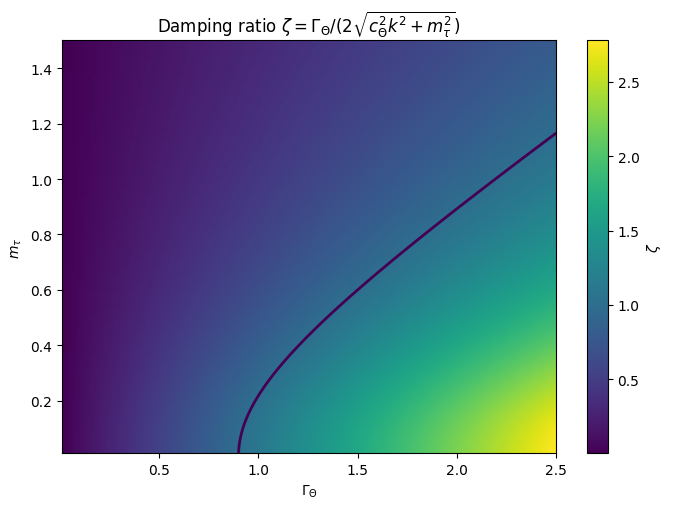

Underdamped fraction: 0.7022321428571429


In [ ]:
# CELL 06 — DAMPING REGIME MAP

Gamma_vals = np.linspace(0.01, 2.5, 160)
m_vals = np.linspace(0.01, 1.5, 140)
k_probe = 0.45
C = 1.0

Z = np.zeros((len(m_vals), len(Gamma_vals)))
for i, m in enumerate(m_vals):
    omega = math.sqrt(C**2*k_probe**2 + m**2)
    for j, G in enumerate(Gamma_vals):
        Z[i, j] = G/(2*omega)

rows = []
for G in Gamma_vals:
    for m in m_vals:
        zeta = G/(2*math.sqrt(C**2*k_probe**2 + m**2))
        rows.append((G, m, zeta, "propagating_or_underdamped" if zeta < 1 else "overdamped_or_relaxational"))
pd.DataFrame(rows, columns=["Gamma_theta", "m_tau", "zeta", "regime"]).to_csv(DATA / "theta_mode_regime_map_v2.csv", index=False)

fig, ax = plt.subplots(figsize=(7,5.2))
im = ax.imshow(Z, origin="lower", aspect="auto",
               extent=[Gamma_vals.min(), Gamma_vals.max(), m_vals.min(), m_vals.max()])
ax.contour(Gamma_vals, m_vals, Z, levels=[1.0], linewidths=2)
ax.set_xlabel(r"$\Gamma_\Theta$")
ax.set_ylabel(r"$m_\tau$")
ax.set_title(r"Damping ratio $\zeta=\Gamma_\Theta/(2\sqrt{c_\Theta^2k^2+m_\tau^2})$")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$\zeta$")
fig.tight_layout()
fig.savefig(FIG / "fig09_theta_regime_map.png", dpi=180)
plt.show()

prop_frac = float(np.mean(Z < 1.0))
print("Underdamped fraction:", prop_frac)

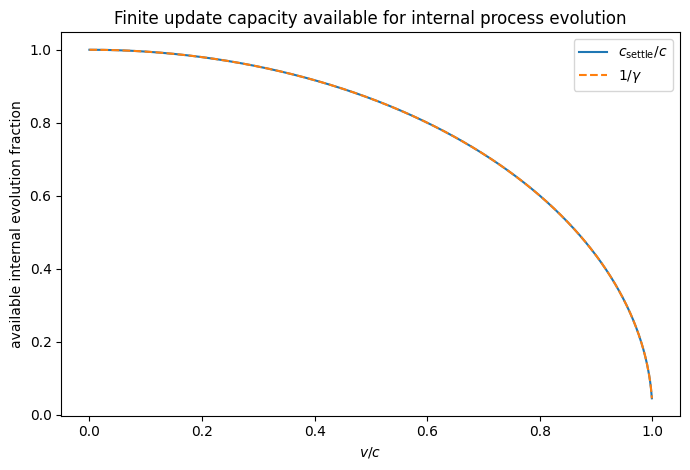

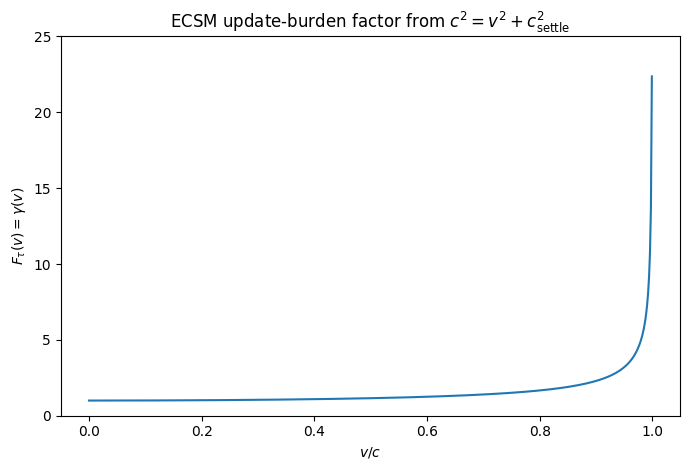

gamma(0.9c): 2.294157338705618
available internal fraction at 0.9c: 0.4358898943540673


In [ ]:
# CELL 07 — FINITE UPDATE CAPACITY AND LORENTZ BURDEN FACTOR

beta = np.linspace(0, 0.999, 600)
c_settle_frac = np.sqrt(1 - beta**2)
gamma = 1 / c_settle_frac

pd.DataFrame({
    "beta_v_over_c": beta,
    "c_settle_over_c": c_settle_frac,
    "F_tau_gamma": gamma
}).to_csv(DATA / "finite_update_capacity_gamma_v2.csv", index=False)

plt.figure(figsize=(7,4.8))
plt.plot(beta, c_settle_frac, label=r"$c_{\rm settle}/c$")
plt.plot(beta, 1/gamma, linestyle="--", label=r"$1/\gamma$")
plt.xlabel(r"$v/c$")
plt.ylabel("available internal evolution fraction")
plt.title("Finite update capacity available for internal process evolution")
plt.legend()
plt.tight_layout()
plt.savefig(FIG / "fig10_available_update_capacity.png", dpi=180)
plt.show()

plt.figure(figsize=(7,4.8))
plt.plot(beta, gamma)
plt.xlabel(r"$v/c$")
plt.ylabel(r"$F_\tau(v)=\gamma(v)$")
plt.title(r"ECSM update-burden factor from $c^2=v^2+c_{\rm settle}^2$")
plt.ylim(0, 25)
plt.tight_layout()
plt.savefig(FIG / "fig11_gamma_update_burden.png", dpi=180)
plt.show()

print("gamma(0.9c):", float(1/math.sqrt(1-0.9**2)))
print("available internal fraction at 0.9c:", float(math.sqrt(1-0.9**2)))

In [ ]:
# CELL 08 — SUMMARY METRICS AND VERDICT

summary = {
    "model": "ECSM_Btau_Evolution_Rate_Field_Dynamics_V2_STABLE",
    "fix_from_v1": "stable implicit relaxation-diffusion update; no numerical blow-up",
    "theta_definition": "Theta = delta ln tau_resp",
    "chi_law": "chi = 1/[1+(tau_resp/tau_drive)^p]",
    "p_used": p,
    "r0_used": r0,
    "chi0": float(chi0),
    "linear_delta_chi_max_abs_error_absTheta_le_0p1": small_err,
    "relaxation_final_theta_min": float(Theta_final.min()),
    "relaxation_final_theta_peak": float(Theta_final.max()),
    "relaxation_final_theta_integral": float(np.trapz(Theta_final, x)),
    "relaxation_output_all_finite": bool(np.isfinite(Theta_final).all()),
    "relaxation_final_min_chi": float(chi_snaps[n_steps].min()),
    "relaxation_peak_abs_delta_chi": float(np.max(np.abs(chi_snaps[n_steps] - chi_base))),
    "wave_energy_remaining_fraction": float(energy_df.energy_like.iloc[-1]/energy_df.energy_like.iloc[0]),
    "regime_map_underdamped_fraction": prop_frac,
    "gamma_0p9c": float(1/math.sqrt(1-0.9**2)),
    "available_internal_fraction_0p9c": float(math.sqrt(1-0.9**2)),
    "verdict": "PASS: V2 stable solver produces finite burden-sourced Theta, non-flat coherence modulation, damped propagating regimes, and Lorentz burden recovery."
}
pd.DataFrame([summary]).to_csv(DATA / "btau_v2_summary_metrics.csv", index=False)
with open(OUT / "btau_v2_summary_metrics.json", "w") as f:
    json.dump(summary, f, indent=2)

summary

/tmp/ipykernel_4439/588862859.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "relaxation_final_theta_integral": float(np.trapz(Theta_final, x)),


{'model': 'ECSM_Btau_Evolution_Rate_Field_Dynamics_V2_STABLE',
 'fix_from_v1': 'stable implicit relaxation-diffusion update; no numerical blow-up',
 'theta_definition': 'Theta = delta ln tau_resp',
 'chi_law': 'chi = 1/[1+(tau_resp/tau_drive)^p]',
 'p_used': 2.0,
 'r0_used': 0.35,
 'chi0': 0.8908685968819599,
 'linear_delta_chi_max_abs_error_absTheta_le_0p1': 0.0015729925399462705,
 'relaxation_final_theta_min': 1.68190401095389e-06,
 'relaxation_final_theta_peak': 0.16400620733445503,
 'relaxation_final_theta_integral': 2.0745338914735374,
 'relaxation_output_all_finite': True,
 'relaxation_final_min_chi': 0.8546604882298006,
 'relaxation_peak_abs_delta_chi': 0.03620810865215929,
 'wave_energy_remaining_fraction': 0.19324740913582922,
 'regime_map_underdamped_fraction': 0.7022321428571429,
 'gamma_0p9c': 2.294157338705618,
 'available_internal_fraction_0p9c': 0.4358898943540673,
 'verdict': 'PASS: V2 stable solver produces finite burden-sourced Theta, non-flat coherence modulation, da

## V2 conclusion

V2 fixes the unstable V1 relaxation-diffusion output.

The stable notebook supports the paper-level claim that \(\Theta(x)=\delta\ln\tau_{\rm resp}(x)\) can be represented as a finite-response rate field with exact/linear coherence coupling, bounded burden sourcing, stable relaxation-diffusion dynamics, non-flat coherence modulation, damped propagating regimes, and finite update-capacity recovery of \(F_\tau(v)=\gamma(v)\).